# Lab 08 — On-Policy Gameplay SFT (v2)

**Goal:** train Qwen on the exact Wordle states it encounters under deployment, while treating the **observable game state**—not the raw learner turn—as the unit of supervision.

Lab 08 v1 exposed two issues:

1. repeated guesses generated many different prompts that represented the same information state;
2. answer-level split priority left only 233 train examples and 367 dev examples after deduplication.

v2 fixes both.

The core unit is now:

```text
canonical observable history
        ↓
symbolic expert action
```

Repeated identical `(guess, feedback)` rows are removed before the prompt is created. Then unique canonical prompts are split deterministically 90/10 into train/dev.

This keeps the on-policy idea while removing repetition-induced duplication and split starvation.

In [1]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path
from collections import Counter
import hashlib, json, math, random, re, time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer

from tiny_wordle.game import Turn, score_string
from tiny_wordle.expert import EntropyExpert

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)
print("PyTorch:", torch.__version__)

device: mps
PyTorch: 2.13.0


## 8.1 Load the Lab 07 checkpoint

In [2]:
LAB07_CHECKPOINT = Path("../checkpoints/qwen3-0.6b-wordle-full-sft")

tokenizer = AutoTokenizer.from_pretrained(LAB07_CHECKPOINT)
model = AutoModelForCausalLM.from_pretrained(
    LAB07_CHECKPOINT,
    dtype=torch.float32,
).to(device)
model.eval()

print(type(model).__name__)
print("parameters:", f"{sum(p.numel() for p in model.parameters()):,}")
print("device:", next(model.parameters()).device)

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForCausalLM
parameters: 596,049,920
device: mps:0


## 8.2 Load the symbolic expert

In [3]:
DATA_DIR = Path("../data")

ANSWERS = [
    x.strip().upper()
    for x in (DATA_DIR / "wordle-answers-original.txt").read_text().splitlines()
    if x.strip()
]
PATTERNS = np.load(DATA_DIR / "wordle-patterns-original-2315.npy")

expert = EntropyExpert(ANSWERS, PATTERNS)
WORD_TO_INDEX = expert.word_to_index
ALL_INDICES = expert.all_indices

print("answers:", len(ANSWERS))
print("pattern matrix:", PATTERNS.shape)

answers: 2315
pattern matrix: (2315, 2315)


## 8.3 Freeze the exact Lab 04 gameplay interface

No prompt changes are allowed in this lab.

In [4]:
SYSTEM_RULES = '''Play Wordle.

Return exactly one uppercase five-letter English word.
Do not explain.
Do not use punctuation.

Use all previous guesses and feedback when choosing the next guess.
Never repeat a previous guess.

Example valid response:
CRANE

Feedback meanings:
G = correct letter and position
Y = letter is present but wrong position
B = that letter occurrence is not matched
'''

def format_history_for_model(history: list[Turn]) -> str:
    if not history:
        return "No guesses have been made yet."

    return "\n".join(
        f"{' '.join(t.guess)} -> {' '.join(t.feedback)}"
        for t in history
    )

def build_prompt(history: list[Turn]) -> str:
    return SYSTEM_RULES + "\nGame history:\n" + format_history_for_model(history)

WORD_RE = re.compile(r"^[A-Za-z]{5}$")

def parse_guess(raw_text: str) -> str | None:
    text = raw_text.strip()
    return text.upper() if WORD_RE.fullmatch(text) else None

## 8.4 Deterministic model generation

In [5]:
def render_prompt(prompt: str) -> str:
    return tokenizer.apply_chat_template(
        [{"role": "user", "content": prompt}],
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )

def generate_raw_guess(history: list[Turn], max_new_tokens: int = 16) -> str:
    text = render_prompt(build_prompt(history))
    batch = tokenizer(text, return_tensors="pt").to(device)

    model.eval()
    with torch.no_grad():
        output = model.generate(
            **batch,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    new = output[0, batch["input_ids"].shape[1]:]
    return tokenizer.decode(new, skip_special_tokens=True).strip()

## 8.5 Recover candidate sets from arbitrary learner histories

In [6]:
MARK_DIGIT = {"B": 0, "Y": 1, "G": 2}

def encode_feedback(feedback: str) -> int:
    value = 0
    for mark in feedback:
        value = value * 3 + MARK_DIGIT[mark]
    return value

def candidate_indices_from_history(history: list[Turn]) -> np.ndarray:
    candidates = ALL_INDICES.copy()

    for turn in history:
        if turn.guess in WORD_TO_INDEX:
            guess_idx = WORD_TO_INDEX[turn.guess]
            pattern_id = encode_feedback(turn.feedback)
            candidates = candidates[
                PATTERNS[guess_idx, candidates] == pattern_id
            ]
        else:
            candidates = np.array(
                [
                    int(idx)
                    for idx in candidates
                    if score_string(ANSWERS[int(idx)], turn.guess) == turn.feedback
                ],
                dtype=np.int32,
            )

        if len(candidates) == 0:
            break

    return candidates

def expert_action_for_history(history: list[Turn]) -> tuple[str | None, int]:
    candidates = candidate_indices_from_history(history)

    if len(candidates) == 0:
        return None, 0

    seen = {t.guess for t in history}
    available = np.array(
        [int(i) for i in candidates if ANSWERS[int(i)] not in seen],
        dtype=np.int32,
    )

    if len(available) == 0:
        return None, len(candidates)

    guess_idx = expert.choose(available)
    return ANSWERS[guess_idx], len(candidates)

## 8.6 Smoke relabel

In [7]:
smoke_history = [Turn("CRANE", "BBGGB")]
expert_guess, candidate_count = expert_action_for_history(smoke_history)

print("candidate count:", candidate_count)
print("expert action:", expert_guess)
print("repeat:", expert_guess == "CRANE")

candidate count: 16
expert action: STANK
repeat: False


## 8.7 Reuse Lab 06 answer partitions for collection only

In [8]:
DEV_FIXED = {"PLANT"}

TEST_FIXED = {
    "SHORE", "MIGHT", "BRICK", "GHOST", "KNIFE",
    "DOUBT", "FLING", "ROUND", "CHAMP", "WASTE",
    "BLIND", "POINT", "SLATE", "CRANE", "APPLE",
    "SHEEP", "BANAL", "ALLEY", "AUDIO",
}

def stable_bucket(word: str) -> int:
    digest = hashlib.sha256(word.encode("utf-8")).digest()
    return int.from_bytes(digest[:8], "big") % 1000

def answer_split(answer: str) -> str:
    if answer in TEST_FIXED:
        return "test"
    if answer in DEV_FIXED:
        return "dev"
    return "dev" if stable_bucket(answer) < 100 else "train"

print(Counter(answer_split(w) for w in ANSWERS))

Counter({'train': 2065, 'dev': 231, 'test': 19})


## 8.8 Collect raw learner turns

In [9]:
@dataclass
class OnPolicyState:
    answer: str
    source_split: str
    turn: int
    history: list[dict]
    learner_raw: str
    learner_guess: str | None
    learner_repeated: bool
    learner_feedback: str | None

def collect_game_states(answer: str, max_turns: int = 6) -> list[OnPolicyState]:
    history: list[Turn] = []
    seen = set()
    records = []

    for turn_number in range(1, max_turns + 1):
        raw = generate_raw_guess(history)
        learner_guess = parse_guess(raw)
        repeated = learner_guess in seen if learner_guess is not None else False

        record = OnPolicyState(
            answer=answer,
            source_split=answer_split(answer),
            turn=turn_number,
            history=[{"guess": t.guess, "feedback": t.feedback} for t in history],
            learner_raw=raw,
            learner_guess=learner_guess,
            learner_repeated=repeated,
            learner_feedback=None,
        )
        records.append(record)

        if learner_guess is None:
            continue

        seen.add(learner_guess)
        feedback = score_string(answer, learner_guess)
        records[-1].learner_feedback = feedback
        history.append(Turn(learner_guess, feedback))

        if feedback == "GGGGG":
            break

    return records

## 8.9 Smoke collection on PLANT

In [10]:
smoke_states = collect_game_states("PLANT")

for s in smoke_states:
    canonical_history = [
        Turn(x["guess"], x["feedback"])
        for x in s.history
    ]
    expert_guess, candidate_count = expert_action_for_history(canonical_history)

    print("=" * 70)
    print("turn:", s.turn)
    print("learner:", s.learner_guess)
    print("feedback:", s.learner_feedback)
    print("expert:", expert_guess)
    print("candidates:", candidate_count)
    print("repeat:", s.learner_repeated)

turn: 1
learner: CRANE
feedback: BBGGB
expert: RAISE
candidates: 2315
repeat: False
turn: 2
learner: CRANE
feedback: BBGGB
expert: STANK
candidates: 16
repeat: True
turn: 3
learner: CRANE
feedback: BBGGB
expert: STANK
candidates: 16
repeat: True
turn: 4
learner: CRANE
feedback: BBGGB
expert: STANK
candidates: 16
repeat: True
turn: 5
learner: CRANE
feedback: BBGGB
expert: STANK
candidates: 16
repeat: True
turn: 6
learner: CRAZE
feedback: BBGBB
expert: STANK
candidates: 16
repeat: False


## 8.10 Collect 1,000 train answers plus all dev answers

In [11]:
TRAIN_COLLECTION_LIMIT = 1000

train_answers = [w for w in ANSWERS if answer_split(w) == "train"]
dev_answers = [w for w in ANSWERS if answer_split(w) == "dev"]

rng = random.Random(SEED)
rng.shuffle(train_answers)

train_collection_answers = train_answers[:TRAIN_COLLECTION_LIMIT]
collection_answers = train_collection_answers + dev_answers

print("train collection answers:", len(train_collection_answers))
print("dev collection answers:", len(dev_answers))

train collection answers: 1000
dev collection answers: 231


In [12]:
start = time.perf_counter()
on_policy_states: list[OnPolicyState] = []

for i, answer in enumerate(collection_answers, 1):
    on_policy_states.extend(collect_game_states(answer))

    if i % 100 == 0 or i == len(collection_answers):
        elapsed = time.perf_counter() - start
        print(
            f"{i:4d}/{len(collection_answers)} answers | "
            f"states={len(on_policy_states)} | "
            f"{elapsed:.1f}s"
        )

 100/1231 answers | states=600 | 40.6s
 200/1231 answers | states=1200 | 81.0s
 300/1231 answers | states=1800 | 121.4s
 400/1231 answers | states=2397 | 161.7s
 500/1231 answers | states=2997 | 202.0s
 600/1231 answers | states=3597 | 242.7s
 700/1231 answers | states=4197 | 283.5s
 800/1231 answers | states=4797 | 324.4s
 900/1231 answers | states=5397 | 365.3s
1000/1231 answers | states=5997 | 406.1s
1100/1231 answers | states=6597 | 446.9s
1200/1231 answers | states=7197 | 488.3s
1231/1231 answers | states=7383 | 501.4s


## 8.11 Raw collection statistics

In [13]:
state_df = pd.DataFrame([asdict(s) for s in on_policy_states])

print("learner turns collected:", len(state_df))
print("repeat learner actions:", int(state_df["learner_repeated"].sum()))
print("\nSOURCE SPLITS")
print(state_df["source_split"].value_counts())

learner turns collected: 7383
repeat learner actions: 5221

SOURCE SPLITS
source_split
train    5997
dev      1386
Name: count, dtype: int64


## 8.12 Canonicalize observable history

Repeated identical observations do not add information.

Example:

```text
CRANE -> GBBYY
CRANE -> GBBYY
CRANE -> GBBYY
```

becomes:

```text
CRANE -> GBBYY
```

We preserve order and remove only exact duplicate `(guess, feedback)` observations.

In [14]:
def canonicalize_history(history_dicts: list[dict]) -> list[Turn]:
    seen = set()
    canonical = []

    for item in history_dicts:
        key = (item["guess"], item["feedback"])

        if key in seen:
            continue

        seen.add(key)
        canonical.append(Turn(item["guess"], item["feedback"]))

    return canonical

## 8.13 Build canonical state → expert action examples

In [15]:
canonical_examples = []

for state in on_policy_states:
    canonical_history = canonicalize_history(state.history)

    expert_guess, candidate_count = expert_action_for_history(
        canonical_history
    )

    if expert_guess is None:
        continue

    prompt = build_prompt(canonical_history)

    canonical_examples.append({
        "source_answer": state.answer,
        "source_turn": state.turn,
        "candidate_count": candidate_count,
        "learner_guess": state.learner_guess,
        "learner_repeated": state.learner_repeated,
        "canonical_history_length": len(canonical_history),
        "prompt": prompt,
        "response": expert_guess,
    })

print("canonical raw examples:", len(canonical_examples))

canonical raw examples: 7383


## 8.14 Reject conflicting targets

In [16]:
prompt_targets = {}

for ex in canonical_examples:
    prompt_targets.setdefault(ex["prompt"], set()).add(ex["response"])

ambiguous = {
    prompt: targets
    for prompt, targets in prompt_targets.items()
    if len(targets) > 1
}

print("ambiguous prompts:", len(ambiguous))

if ambiguous:
    for prompt, targets in list(ambiguous.items())[:10]:
        print("=" * 80)
        print(prompt)
        print("targets:", targets)

assert not ambiguous

ambiguous prompts: 0


## 8.15 Deduplicate by canonical observable state

In [17]:
dedup = {}

for ex in canonical_examples:
    key = (ex["prompt"], ex["response"])
    existing = dedup.get(key)

    if existing is None:
        dedup[key] = ex
    else:
        existing["learner_repeated"] = (
            existing["learner_repeated"]
            or ex["learner_repeated"]
        )

unique_examples = list(dedup.values())

print("learner turns collected:", len(on_policy_states))
print("canonical generated examples:", len(canonical_examples))
print("unique canonical states:", len(unique_examples))

learner turns collected: 7383
canonical generated examples: 7383
unique canonical states: 142


## 8.16 Split by canonical prompt

At this point, source hidden answer is no longer the relevant unit. Multiple answers can produce the same observable state.

So the **canonical prompt itself** is deterministically split:

```text
~90% train
~10% dev
```

The unique opening state is forced into train.

In [18]:
def prompt_bucket(prompt: str) -> int:
    digest = hashlib.sha256(prompt.encode("utf-8")).digest()
    return int.from_bytes(digest[:8], "big") % 1000

for ex in unique_examples:
    if "No guesses have been made yet." in ex["prompt"]:
        ex["split"] = "train"
    else:
        ex["split"] = "dev" if prompt_bucket(ex["prompt"]) < 100 else "train"

examples_df = pd.DataFrame(unique_examples)

print(examples_df["split"].value_counts())
print("\nrepetition-derived unique states:", int(examples_df["learner_repeated"].sum()))

split
train    129
dev       13
Name: count, dtype: int64

repetition-derived unique states: 141


## 8.17 Assert prompt isolation

In [19]:
prompt_splits = (
    examples_df[["prompt", "split"]]
    .drop_duplicates()
    .groupby("prompt")["split"]
    .nunique()
)

assert prompt_splits.max() == 1

print("No model-facing prompt appears in multiple splits.")

No model-facing prompt appears in multiple splits.


## 8.18 Inspect canonical repetition corrections

In [20]:
repeat_examples = examples_df.loc[examples_df["learner_repeated"]]

print("repetition-derived unique states:", len(repeat_examples))

sample = repeat_examples.sample(
    min(10, len(repeat_examples)),
    random_state=SEED,
)

for _, row in sample.iterrows():
    print("=" * 80)
    print(row["prompt"])
    print("\nLEARNER:", row["learner_guess"])
    print("EXPERT TARGET:", row["response"])

repetition-derived unique states: 141
Play Wordle.

Return exactly one uppercase five-letter English word.
Do not explain.
Do not use punctuation.

Use all previous guesses and feedback when choosing the next guess.
Never repeat a previous guess.

Example valid response:
CRANE

Feedback meanings:
G = correct letter and position
Y = letter is present but wrong position
B = that letter occurrence is not matched

Game history:
C R A N E -> B G G Y B

LEARNER: CRANE
EXPERT TARGET: BRAIN
Play Wordle.

Return exactly one uppercase five-letter English word.
Do not explain.
Do not use punctuation.

Use all previous guesses and feedback when choosing the next guess.
Never repeat a previous guess.

Example valid response:
CRANE

Feedback meanings:
G = correct letter and position
Y = letter is present but wrong position
B = that letter occurrence is not matched

Game history:
C R A N E -> B B Y G G

LEARNER: CRANE
EXPERT TARGET: ALONE
Play Wordle.

Return exactly one uppercase five-letter English

## 8.19 Persist the corrected on-policy dataset

In [21]:
GENERATED_DIR = DATA_DIR / "generated"
GENERATED_DIR.mkdir(parents=True, exist_ok=True)

train_df = examples_df.loc[examples_df["split"] == "train"].copy()
dev_df = examples_df.loc[examples_df["split"] == "dev"].copy()

train_path = GENERATED_DIR / "wordle-onpolicy-v2-train.jsonl"
dev_path = GENERATED_DIR / "wordle-onpolicy-v2-dev.jsonl"

train_df.to_json(train_path, orient="records", lines=True, force_ascii=False)
dev_df.to_json(dev_path, orient="records", lines=True, force_ascii=False)

print("train:", len(train_df), train_path)
print("dev:", len(dev_df), dev_path)

train: 129 ../data/generated/wordle-onpolicy-v2-train.jsonl
dev: 13 ../data/generated/wordle-onpolicy-v2-dev.jsonl


# Phase 2 — Full-parameter adaptation on canonical deployment states

## 8.20 Measure sequence lengths

In [22]:
def render_full_example(prompt: str, response: str) -> tuple[str, str]:
    prompt_text = render_prompt(prompt)
    return prompt_text, prompt_text + response + tokenizer.eos_token

def sequence_length(row) -> int:
    _, full_text = render_full_example(row["prompt"], row["response"])
    return len(tokenizer.encode(full_text, add_special_tokens=False))

max_train_length = max(sequence_length(r) for _, r in train_df.iterrows())
max_dev_length = max(sequence_length(r) for _, r in dev_df.iterrows())

print("max train length:", max_train_length)
print("max dev length:", max_dev_length)

MAX_LENGTH = max(128, max_train_length + 4, max_dev_length + 4)
print("MAX_LENGTH:", MAX_LENGTH)

max train length: 117
max dev length: 105
MAX_LENGTH: 128


## 8.21 Response-only encoding and loaders

In [23]:
def encode_example(row) -> dict:
    prompt_text, full_text = render_full_example(row["prompt"], row["response"])

    prompt_ids = tokenizer(prompt_text, add_special_tokens=False)["input_ids"]
    full_ids = tokenizer(full_text, add_special_tokens=False)["input_ids"]

    if len(full_ids) > MAX_LENGTH:
        raise ValueError(f"{len(full_ids)} > MAX_LENGTH {MAX_LENGTH}")

    labels = [-100] * len(prompt_ids) + full_ids[len(prompt_ids):]

    return {"input_ids": full_ids, "labels": labels}

PAD_ID = tokenizer.pad_token_id or tokenizer.eos_token_id

def collate_batch(rows):
    encoded = [encode_example(row) for row in rows]
    max_len = max(len(x["input_ids"]) for x in encoded)

    input_rows, label_rows, attention_rows = [], [], []

    for item in encoded:
        ids, labels = item["input_ids"], item["labels"]
        pad = max_len - len(ids)

        input_rows.append(ids + [PAD_ID] * pad)
        label_rows.append(labels + [-100] * pad)
        attention_rows.append([1] * len(ids) + [0] * pad)

    return {
        "input_ids": torch.tensor(input_rows, dtype=torch.long),
        "labels": torch.tensor(label_rows, dtype=torch.long),
        "attention_mask": torch.tensor(attention_rows, dtype=torch.long),
    }

BATCH_SIZE = 16
VAL_BATCH_SIZE = 32

train_records = train_df.to_dict("records")
dev_records = dev_df.to_dict("records")

train_loader = DataLoader(
    train_records,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch,
    generator=torch.Generator().manual_seed(SEED),
)
val_loader = DataLoader(
    dev_records,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
)

print("train batches:", len(train_loader))
print("dev batches:", len(val_loader))

train batches: 9
dev batches: 1


## 8.22 Baseline on-policy validation loss

In [24]:
@torch.no_grad()
def evaluate_loss(model, loader) -> float:
    model.eval()
    losses = []

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        losses.append(outputs.loss.detach().float().cpu().item())

    model.train()
    return float(np.mean(losses))

baseline_onpolicy_val_loss = evaluate_loss(model, val_loader)
print("baseline on-policy validation loss:", baseline_onpolicy_val_loss)

baseline on-policy validation loss: 3.773045539855957


## 8.23 Training configuration

In [25]:
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
EPOCHS = 10

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

total_steps = len(train_loader) * EPOCHS
warmup_steps = max(1, int(total_steps * 0.05))

def lr_multiplier(step: int) -> float:
    if step < warmup_steps:
        return (step + 1) / warmup_steps

    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lr_multiplier,
)

print("total steps:", total_steps)
print("warmup steps:", warmup_steps)

total steps: 90
warmup steps: 4


## 8.24 One-batch sanity check

In [26]:
batch = next(iter(train_loader))
batch = {k: v.to(device) for k, v in batch.items()}

model.train()
optimizer.zero_grad(set_to_none=True)

outputs = model(**batch)
loss = outputs.loss
loss.backward()

grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

print("sanity loss:", loss.detach().float().cpu().item())
print("gradient norm before clipping:", float(grad_norm))

optimizer.zero_grad(set_to_none=True)

sanity loss: 4.484977722167969
gradient norm before clipping: 59.75286102294922


## 8.25 Train

In [27]:
CHECKPOINT_DIR = Path("../checkpoints/qwen3-0.6b-wordle-onpolicy-sft-v2")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

LOG_EVERY = 10
EVAL_EVERY = 20 # max(10, total_steps // 5)

history = []
best_val_loss = float("inf")
global_step = 0
start = time.perf_counter()

model.train()

for epoch in range(EPOCHS):
    for batch in train_loader:
        global_step += 1
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad(set_to_none=True)

        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()

        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        loss_value = loss.detach().float().cpu().item()
        lr = scheduler.get_last_lr()[0]

        history.append({
            "step": global_step,
            "train_loss": loss_value,
            "lr": lr,
            "grad_norm": float(grad_norm),
            "val_loss": None,
        })

        if global_step == 1 or global_step % LOG_EVERY == 0:
            elapsed = time.perf_counter() - start
            print(
                f"step {global_step:4d}/{total_steps} | "
                f"loss {loss_value:.4f} | "
                f"lr {lr:.2e} | "
                f"grad {float(grad_norm):.3f} | "
                f"{elapsed:.1f}s"
            )

        should_eval = global_step % EVAL_EVERY == 0 or global_step == total_steps

        if should_eval:
            val_loss = evaluate_loss(model, val_loader)
            history[-1]["val_loss"] = val_loss

            print(f"  validation @ step {global_step}: {val_loss:.4f}")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                print("  new best validation loss; saving checkpoint")
                model.save_pretrained(CHECKPOINT_DIR, safe_serialization=True)
                tokenizer.save_pretrained(CHECKPOINT_DIR)

            model.train()

elapsed = time.perf_counter() - start

print("\ntraining complete")
print("elapsed seconds:", elapsed)
print("best validation loss:", best_val_loss)

step    1/90 | loss 3.7791 | lr 5.00e-06 | grad 49.732 | 1.9s
step   10/90 | loss 2.5290 | lr 9.88e-06 | grad 16.876 | 18.1s
step   20/90 | loss 1.9465 | lr 9.17e-06 | grad 16.763 | 35.5s
  validation @ step 20: 3.1062
  new best validation loss; saving checkpoint


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

step   30/90 | loss 1.7350 | lr 7.91e-06 | grad 19.084 | 53.9s
step   40/90 | loss 1.4602 | lr 6.26e-06 | grad 18.619 | 71.3s
  validation @ step 40: 3.3826
step   50/90 | loss 0.9670 | lr 4.45e-06 | grad 19.901 | 88.9s
step   60/90 | loss 1.1377 | lr 2.71e-06 | grad 31.369 | 106.3s
  validation @ step 60: 3.7312
step   70/90 | loss 0.8618 | lr 1.28e-06 | grad 28.301 | 123.9s
step   80/90 | loss 0.6533 | lr 3.30e-07 | grad 32.983 | 141.3s
  validation @ step 80: 4.0500
step   90/90 | loss 0.5598 | lr 0.00e+00 | grad 167.852 | 158.2s
  validation @ step 90: 4.0526

training complete
elapsed seconds: 158.32861708302516
best validation loss: 3.106171131134033


## 8.26 Plot training

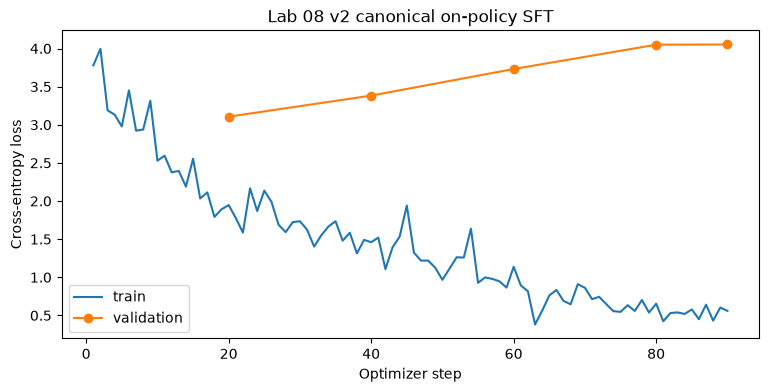

In [28]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(9, 4))
plt.plot(history_df["step"], history_df["train_loss"], label="train")

val_points = history_df.dropna(subset=["val_loss"])
plt.plot(
    val_points["step"],
    val_points["val_loss"],
    marker="o",
    label="validation",
)

plt.xlabel("Optimizer step")
plt.ylabel("Cross-entropy loss")
plt.title("Lab 08 v2 canonical on-policy SFT")
plt.legend()
plt.show()

## 8.27 Reload best checkpoint

In [29]:
del model

if device.type == "mps":
    torch.mps.empty_cache()

model = AutoModelForCausalLM.from_pretrained(
    CHECKPOINT_DIR,
    dtype=torch.float32,
).to(device)

model.eval()
print("reloaded:", CHECKPOINT_DIR)

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

reloaded: ../checkpoints/qwen3-0.6b-wordle-onpolicy-sft-v2


# Phase 3 — Frozen Lab 04 benchmark

In Lab 04, change **only**:

```python
MODEL_ID = "../checkpoints/qwen3-0.6b-wordle-onpolicy-sft-v2"
```

Do not change prompt, parser, answer set, thinking mode, decoding, or rules.

Run `PLANT` first, then the full benchmark.

Record:

- solve rate
- feedback-dependent solves
- valid output rate
- repeat guesses
- history consistency rate
- mean turns on wins

Interpretation:

- repetition falls and consistency rises → the on-policy hypothesis worked;
- consistency rises but solve rate remains low → strategy is the next bottleneck;
- gameplay remains unchanged → one canonical on-policy round was insufficient.

# Lab 08 v2 checkpoint

Send me:

1. smoke relabel;
2. raw learner-turn count;
3. canonical raw example count;
4. unique canonical state count;
5. ambiguous prompt count;
6. train/dev counts after prompt-level split;
7. repetition-derived unique state count;
8. max sequence lengths;
9. baseline on-policy validation loss;
10. sanity loss + gradient norm;
11. training validation checkpoints;
12. post-training PLANT trace;
13. full frozen Lab 04 metrics.